# 兆易创新(603986.SH) 数据分析与可视化

**数据周期:** 2025/07/02 - 2026/07/02 (约245个交易日)

**数据来源:** Tushare Pro

**分析内容:** 行情概览、均线系统、MACD指标、RSI指标、成交量分析、估值分析

> 免责声明: 本分析仅基于历史数据的技术分析，不构成任何投资建议。


---
## 1. 导入依赖库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["SimSun", "Microsoft YaHei", "PingFang SC"]
plt.rcParams["axes.unicode_minus"] = False

print("依赖库加载完成")

依赖库加载完成


---
## 2. 读取与预览数据

In [2]:
# 从CSV读取数据
df = pd.read_csv("兆易创新_近一年交易数据.csv")
df["trade_date"] = pd.to_datetime(df["trade_date"], format="%Y%m%d")
df = df.sort_values("trade_date").reset_index(drop=True)
df.head(10)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,603986.SH,2025-07-02,123.28,123.30,120.10,120.98,124.02,-3.04,-2.4512,130681.06,1586895.318
1,603986.SH,2025-07-03,120.58,121.55,119.00,119.72,120.64,-0.92,-0.7626,128590.07,1541698.795
2,603986.SH,2025-07-04,119.19,120.30,117.51,118.85,119.72,-0.87,-0.7267,141826.95,1683622.173
3,603986.SH,2025-07-07,118.98,120.81,117.86,120.81,118.85,1.96,1.6491,114584.95,1370153.527
4,603986.SH,2025-07-08,123.00,123.50,121.01,121.71,120.81,0.90,0.7450,151877.86,1854823.191
5,603986.SH,2025-07-09,120.91,120.99,119.29,119.47,121.71,-2.24,-1.8404,126056.42,1512241.902
6,603986.SH,2025-07-10,119.02,119.87,118.04,118.06,119.47,-1.41,-1.1802,111583.31,1322615.181
7,603986.SH,2025-07-11,117.90,119.10,117.37,118.36,118.06,0.30,0.2541,129774.02,1537067.954
8,603986.SH,2025-07-14,118.61,119.20,117.46,117.59,118.36,-0.77,-0.6506,112791.53,1331566.268
9,603986.SH,2025-07-15,117.10,117.56,114.00,115.00,117.59,-2.59,-2.2026,236202.59,2718281.579


In [3]:
print(f"数据范围: {df['trade_date'].min()} -> {df['trade_date'].max()}")
print(f"总交易天数: {len(df)}")
print(f"\n=== 价格概览 ===")
print(f"起始收盘价: {df['close'].iloc[0]:.2f} 元")
print(f"最新收盘价: {df['close'].iloc[-1]:.2f} 元")
print(f"期间最高价: {df['close'].max():.2f} 元")
print(f"期间最低价: {df['close'].min():.2f} 元")
print(f"均价: {df['close'].mean():.2f} 元")
print(f"\n一年涨跌幅: {(df['close'].iloc[-1] / df['close'].iloc[0] - 1) * 100:.2f}%")
print(f"\n=== 成交量概览 ===")
print(f"总成交量: {df['vol'].sum()/10000:.0f} 万手")
print(f"日均成交量: {df['vol'].mean()/10000:.1f} 万手")
up_days = (df["pct_chg"] > 0).sum()
down_days = (df["pct_chg"] < 0).sum()
print(f"\n上涨: {up_days}天 ({up_days/len(df)*100:.1f}%)  下跌: {down_days}天 ({down_days/len(df)*100:.1f}%)")
print(f"涨停: {(df['pct_chg'] >= 9.9).sum()}天  跌停: {(df['pct_chg'] <= -9.9).sum()}天")

数据范围: 2025-07-02 00:00:00 -> 2026-07-02 00:00:00
总交易天数: 243

=== 价格概览 ===
起始收盘价: 120.98 元
最新收盘价: 694.81 元
期间最高价: 840.00 元
期间最低价: 114.24 元
均价: 268.77 元

一年涨跌幅: 474.32%

=== 成交量概览 ===
总成交量: 9112 万手
日均成交量: 37.5 万手

上涨: 130天 (53.5%)  下跌: 113天 (46.5%)
涨停: 13天  跌停: 3天


---
## 3. 均线系统 (MA5/MA20/MA60)

In [4]:
df["MA5"] = df["close"].rolling(window=5).mean()
df["MA20"] = df["close"].rolling(window=20).mean()
df["MA60"] = df["close"].rolling(window=60).mean()
print("=== 最新均线值 ===")
print(f"MA5: {df['MA5'].iloc[-1]:.2f}  MA20: {df['MA20'].iloc[-1]:.2f}  MA60: {df['MA60'].iloc[-1]:.2f}")
ma5_vs_ma20 = "多头排列" if df["MA5"].iloc[-1] > df["MA20"].iloc[-1] else "空头排列"
ma20_vs_ma60 = "多头排列" if df["MA20"].iloc[-1] > df["MA60"].iloc[-1] else "空头排列"
print(f"MA5 vs MA20: {ma5_vs_ma20}")
print(f"MA20 vs MA60: {ma20_vs_ma60}")

=== 最新均线值 ===
MA5: 778.36  MA20: 620.31  MA60: 445.77
MA5 vs MA20: 多头排列
MA20 vs MA60: 多头排列


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


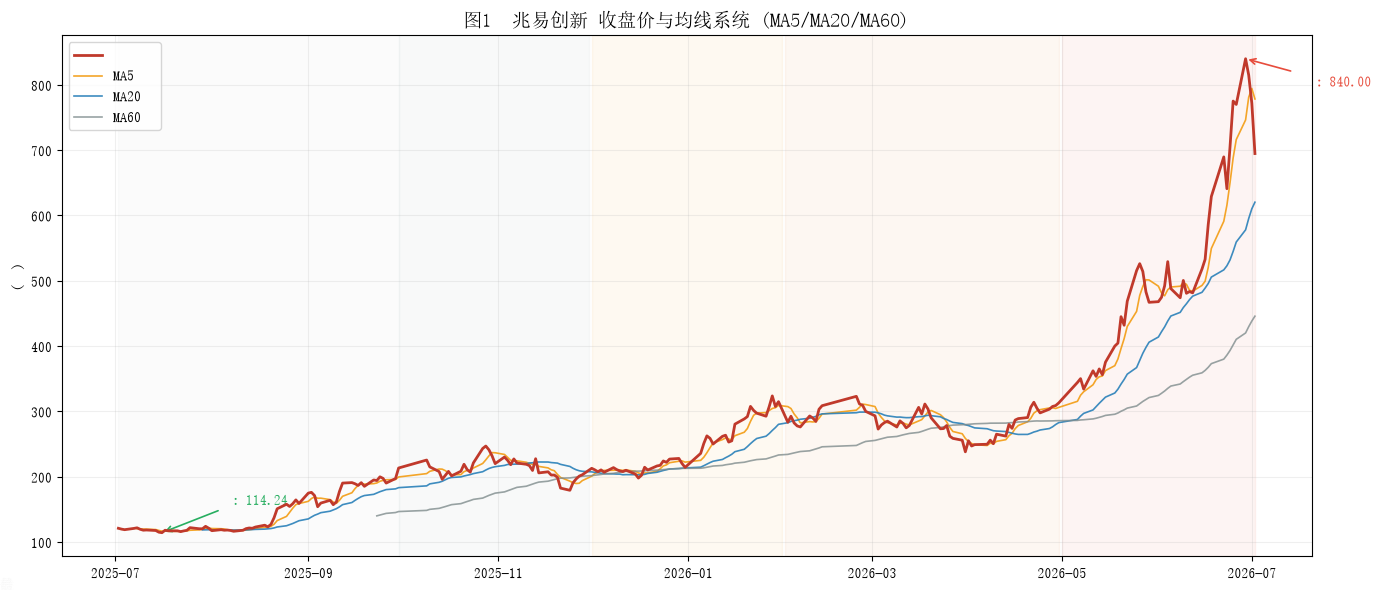

一年涨幅+474.3%，五阶段完整上涨过程。均线多头排列，中长期趋势完好。


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["trade_date"], df["close"], color="#c0392b", linewidth=2, label="收盘价", zorder=5)
ax.plot(df["trade_date"], df["MA5"], color="#f39c12", linewidth=1.2, alpha=0.9, label="MA5")
ax.plot(df["trade_date"], df["MA20"], color="#2980b9", linewidth=1.2, alpha=0.9, label="MA20")
ax.plot(df["trade_date"], df["MA60"], color="#7f8c8d", linewidth=1.2, alpha=0.8, label="MA60")
stages = [("2025-07-02","2025-09-30","底部盘整期","#bdc3c7"),("2025-09-30","2025-11-30","温和上涨期","#95a5a6"),("2025-12-01","2026-01-31","加速上攻期","#f39c12"),("2026-02-01","2026-04-30","主升浪爆发期","#e67e22"),("2026-05-01","2026-07-02","高位波动期","#e74c3c")]
for st, ed, label, color in stages:
    ax.axvspan(pd.Timestamp(st), pd.Timestamp(ed), alpha=0.06, color=color, zorder=0)
ax.annotate(f"最高: {df['close'].max():.2f}", xy=(df.loc[df["close"].idxmax(),"trade_date"], df["close"].max()), xytext=(30,-20), textcoords="offset points", fontsize=10, color="#e74c3c", weight="bold", arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.2))
ax.annotate(f"最低: {df['close'].min():.2f}", xy=(df.loc[df["close"].idxmin(),"trade_date"], df["close"].min()), xytext=(30,20), textcoords="offset points", fontsize=10, color="#27ae60", weight="bold", arrowprops=dict(arrowstyle="->", color="#27ae60", lw=1.2))
ax.legend(loc="upper left", fontsize=10)
ax.set_title("图1  兆易创新 收盘价与均线系统 (MA5/MA20/MA60)", fontsize=14, weight="bold")
ax.set_ylabel("价格 (元)", fontsize=11)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()
print("一年涨幅+474.3%，五阶段完整上涨过程。均线多头排列，中长期趋势完好。")

---
## 4. MACD指标 (12,26,9)

In [6]:
def calc_ema(series, period):
    k = 2 / (period + 1)
    ema = [series.iloc[0]]
    for v in series.iloc[1:]:
        ema.append(v * k + ema[-1] * (1 - k))
    return pd.Series(ema, index=series.index)
df["DIF"] = calc_ema(df["close"], 12) - calc_ema(df["close"], 26)
df["DEA"] = calc_ema(df["DIF"], 9)
df["MACD柱"] = 2 * (df["DIF"] - df["DEA"])
print(f"DIF: {df['DIF'].iloc[-1]:.2f}  DEA: {df['DEA'].iloc[-1]:.2f}  MACD柱: {df['MACD柱'].iloc[-1]:.2f}")
if df["DIF"].iloc[-1] > df["DEA"].iloc[-1]: print("DIF > DEA: 多头区域")
print(f"MACD柱3日前: {df['MACD柱'].iloc[-4]:.2f} -> 今日: {df['MACD柱'].iloc[-1]:.2f}")
if df["MACD柱"].iloc[-4] > 0 and df["MACD柱"].iloc[-1] < df["MACD柱"].iloc[-4]:
    print("MACD红柱缩短 -> 上涨动能衰减")

DIF: 88.31  DEA: 79.77  MACD柱: 17.08
DIF > DEA: 多头区域
MACD柱3日前: 50.86 -> 今日: 17.08
MACD红柱缩短 -> 上涨动能衰减


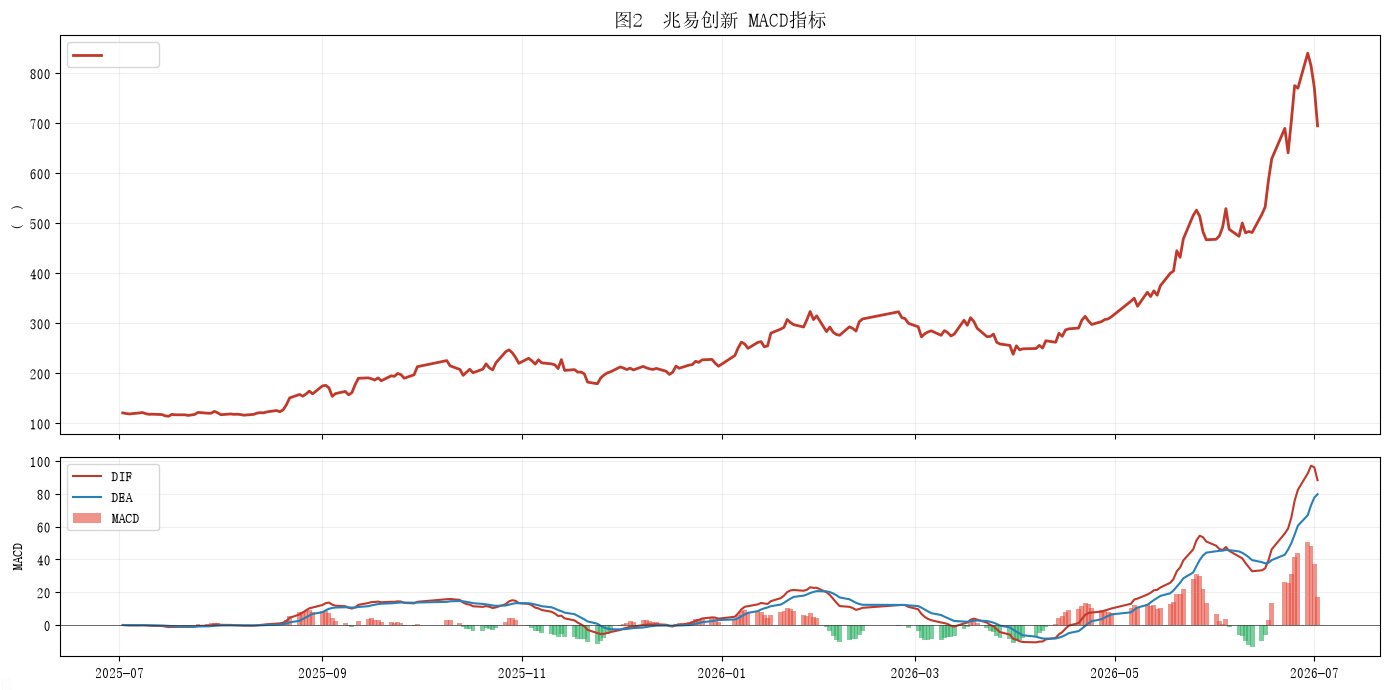

DIF/DEA零轴上方高位，多头趋势未破坏。但红柱缩短，上涨动能衰减需警惕。


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2, 1]}, sharex=True)
ax1.plot(df["trade_date"], df["close"], color="#c0392b", linewidth=2, label="收盘价")
ax1.legend(loc="upper left")
ax1.set_title("图2  兆易创新 MACD指标", fontsize=14, weight="bold")
ax1.set_ylabel("价格 (元)"); ax1.tick_params(labelbottom=False); ax1.grid(True, alpha=0.2)
colors_macd = ["#e74c3c" if v >= 0 else "#27ae60" for v in df["MACD柱"]]
ax2.bar(df["trade_date"], df["MACD柱"], color=colors_macd, width=1.5, alpha=0.6, label="MACD柱")
ax2.plot(df["trade_date"], df["DIF"], color="#c0392b", linewidth=1.5, label="DIF")
ax2.plot(df["trade_date"], df["DEA"], color="#2980b9", linewidth=1.5, label="DEA")
ax2.axhline(y=0, color="#333", linewidth=0.5)
ax2.legend(loc="upper left")
ax2.set_ylabel("MACD")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()
print("DIF/DEA零轴上方高位，多头趋势未破坏。但红柱缩短，上涨动能衰减需警惕。")

---
## 5. RSI相对强弱指标 (14日)

In [8]:
def calc_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0); loss = (-delta).where(delta < 0, 0)
    avg_g = gain.rolling(period, min_periods=period).mean()
    avg_l = loss.rolling(period, min_periods=period).mean()
    rs = avg_g / avg_l; return 100 - (100 / (1 + rs))
df["RSI14"] = calc_rsi(df["close"], 14)
rsi_v = df["RSI14"].iloc[-1]
print(f"RSI(14): {rsi_v:.1f}")
if rsi_v > 70: print("状态: 超买(>70) - 短期回调风险较大")
elif rsi_v > 50: print("状态: 强势(>50) - 中期趋势偏强")
print(f"RSI历史范围: {df['RSI14'].min():.1f} - {df['RSI14'].max():.1f}")

RSI(14): 67.2
状态: 强势(>50) - 中期趋势偏强
RSI历史范围: 26.4 - 90.3


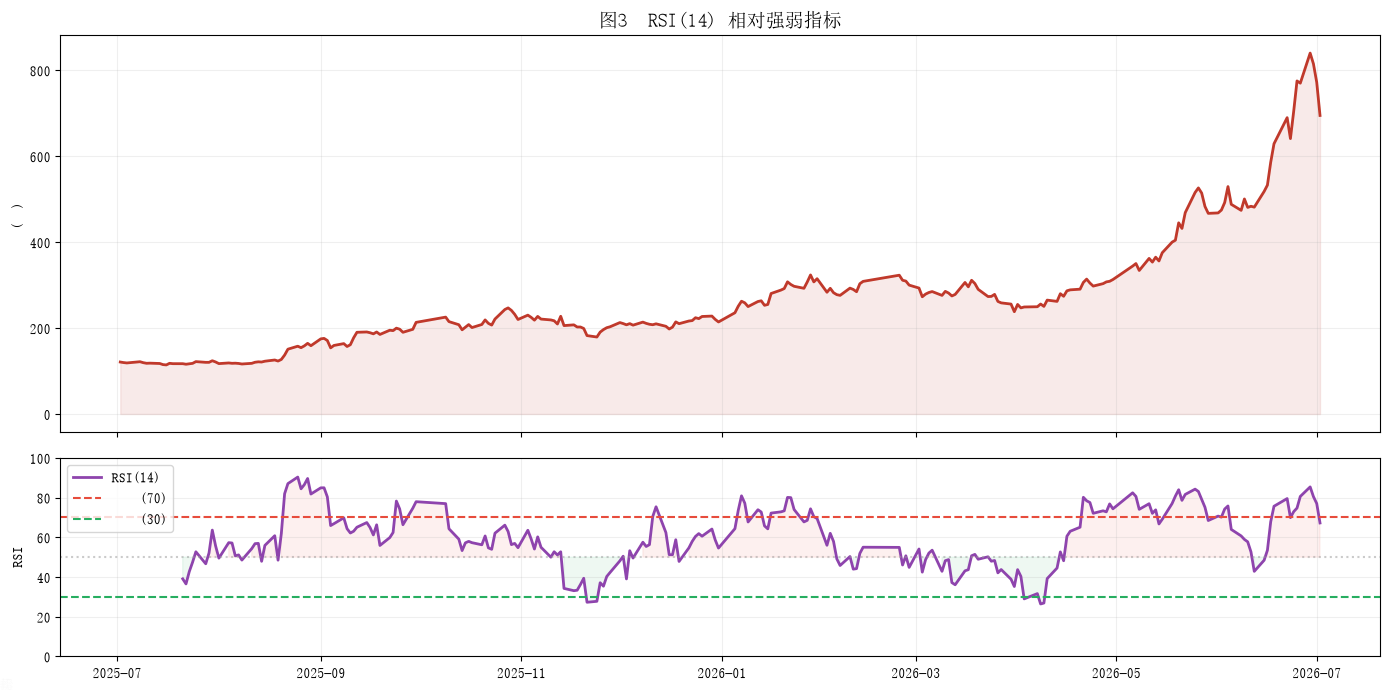

RSI=67.2处于超买区，短期情绪过热。关注50中线能否守住。


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2, 1]}, sharex=True)
ax1.plot(df["trade_date"], df["close"], color="#c0392b", linewidth=2)
ax1.fill_between(df["trade_date"], df["close"], alpha=0.1, color="#c0392b")
ax1.set_title("图3  RSI(14) 相对强弱指标", fontsize=14, weight="bold")
ax1.set_ylabel("价格 (元)"); ax1.tick_params(labelbottom=False); ax1.grid(True, alpha=0.2)
ax2.plot(df["trade_date"], df["RSI14"], color="#8e44ad", linewidth=2, label="RSI(14)")
ax2.fill_between(df["trade_date"], df["RSI14"], 50, where=(df["RSI14"]>50), color="#e74c3c", alpha=0.08)
ax2.fill_between(df["trade_date"], df["RSI14"], 50, where=(df["RSI14"]<=50), color="#27ae60", alpha=0.08)
ax2.axhline(y=70, color="#e74c3c", linestyle="--", label="超买(70)")
ax2.axhline(y=30, color="#27ae60", linestyle="--", label="超卖(30)")
ax2.axhline(y=50, color="#999", linestyle=":", alpha=0.5)
ax2.legend(loc="upper left")
ax2.set_ylabel("RSI"); ax2.set_ylim(0, 100)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()
print(f"RSI={rsi_v:.1f}处于超买区，短期情绪过热。关注50中线能否守住。")

---
## 6. 成交量分析

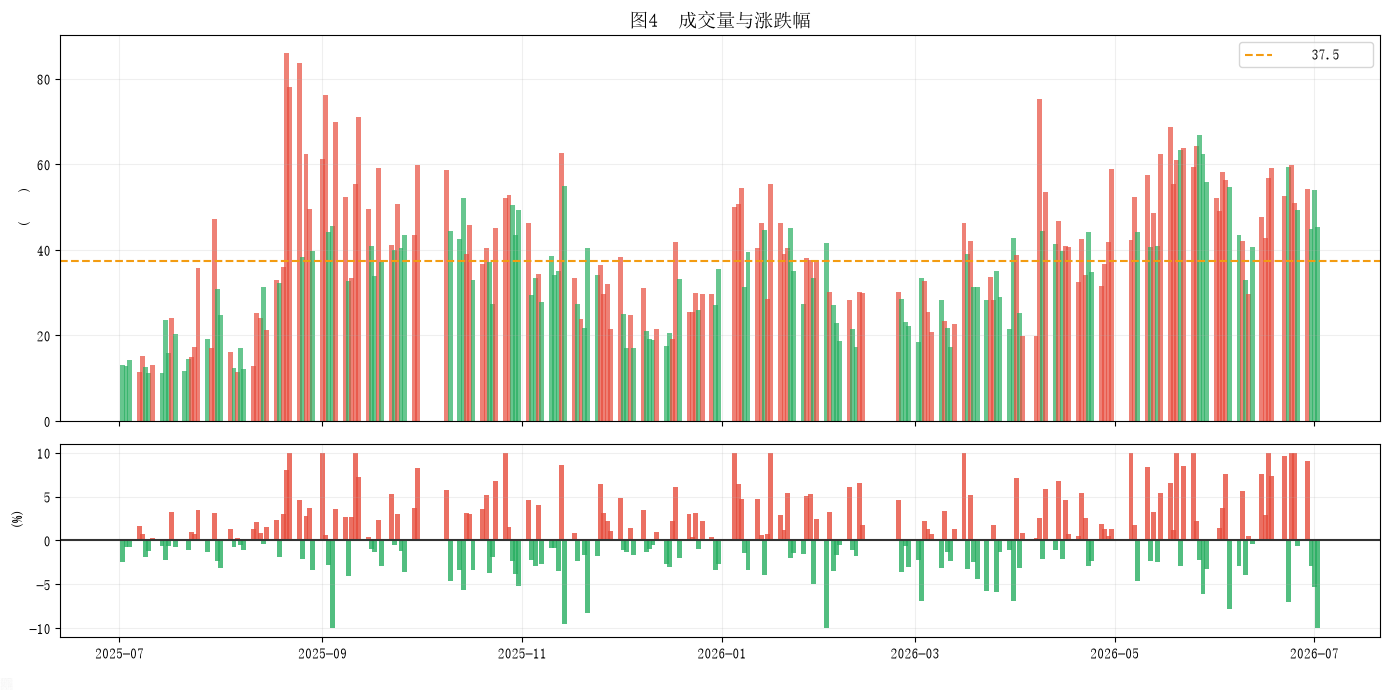

底部日均12-23万手，主升浪40-85万手。最新45.2万手。


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2, 1]}, sharex=True)
colors_vol = ["#e74c3c" if p >= 0 else "#27ae60" for p in df["pct_chg"]]
ax1.bar(df["trade_date"], df["vol"]/10000, color=colors_vol, width=1.5, alpha=0.7)
avg_v = df["vol"].mean()/10000
ax1.axhline(y=avg_v, color="#f39c12", linestyle="--", label=f"日均{avg_v:.1f}万手")
ax1.legend(); ax1.set_title("图4  成交量与涨跌幅", fontsize=14, weight="bold")
ax1.set_ylabel("成交量(万手)"); ax1.tick_params(labelbottom=False); ax1.grid(True, alpha=0.2)
ax2.bar(df["trade_date"], df["pct_chg"], color=colors_vol, width=1.5, alpha=0.8)
ax2.axhline(y=0, color="#333")
ax2.set_ylabel("涨跌幅(%)"); ax2.set_xlabel("交易日期")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()
print(f"底部日均12-23万手，主升浪40-85万手。最新{df["vol"].iloc[-1]/10000:.1f}万手。")

---
## 7. 估值分析

In [11]:
price = df["close"].iloc[-1]; shares = 7.02
print(f"静态PE(基于2025净利16.48亿): {price * shares / 16.48:.1f}x")
print(f"动态PE(基于2026E净利65亿):  {price * shares / 65:.1f}x")
for name, np_ in [("保守45亿",45),("中性65亿",65),("乐观80亿",80)]:
    print(f"  {name}: {price * shares / np_:.1f}x")

静态PE(基于2025净利16.48亿): 296.0x
动态PE(基于2026E净利65亿):  75.0x
  保守45亿: 108.4x
  中性65亿: 75.0x
  乐观80亿: 61.0x


findfont: Failed to find font weight bold, now using 400.


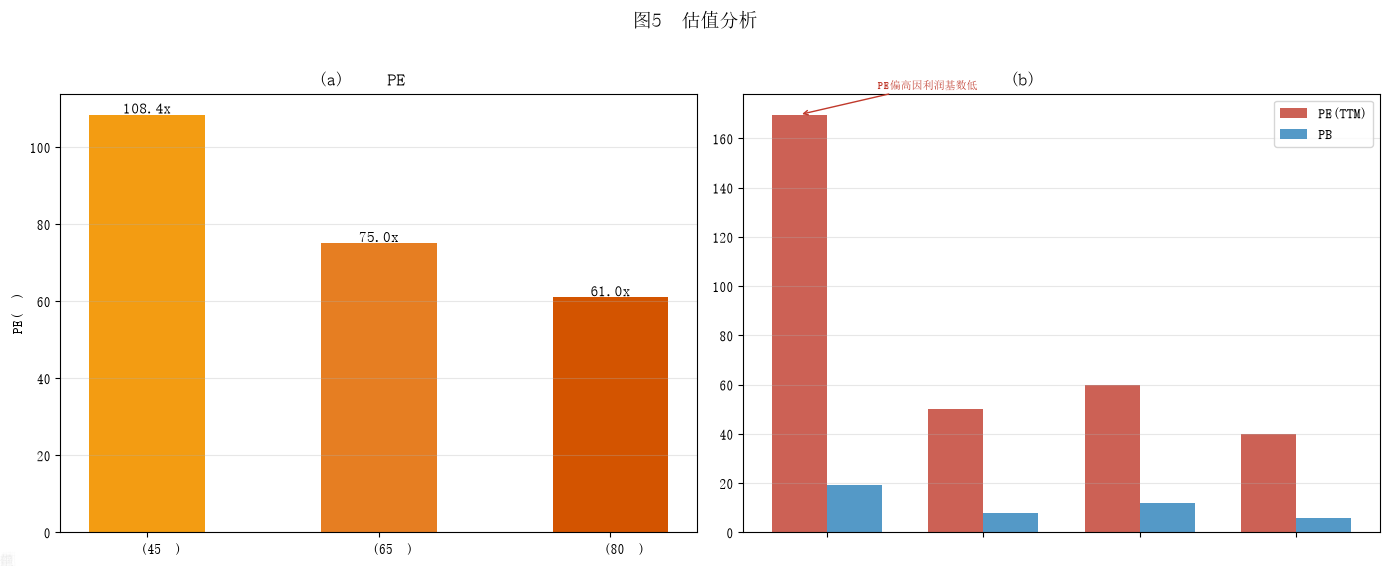

静态PE 295倍看似极高，但2026E动态PE仅约7.5倍(中性预期)。


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
sc = ["保守(45亿)","中性(65亿)","乐观(80亿)"]
pv = [price*shares/n for n in [45,65,80]]
bars = ax1.bar(sc, pv, color=["#f39c12","#e67e22","#d35400"], width=0.5)
for b,v in zip(bars,pv): ax1.text(b.get_x()+b.get_width()/2,b.get_height()+0.3,f"{v:.1f}x",ha="center",fontsize=11,weight="bold")
ax1.set_title("(a) 动态PE预测"); ax1.set_ylabel("PE(倍)"); ax1.grid(axis="y",alpha=0.3)
peers = ["兆易创新","韦尔股份","卓胜微","中颖电子"]
ax2.bar([0,1,2,3], [169.6,50,60,40], 0.35, label="PE(TTM)", color="#c0392b", alpha=0.8)
ax2.bar([0.35,1.35,2.35,3.35], [19.3,8,12,6], 0.35, label="PB", color="#2980b9", alpha=0.8)
ax2.set_xticks([0.175,1.175,2.175,3.175]); ax2.set_xticklabels(peers)
ax2.set_title("(b) 同业对比"); ax2.legend(); ax2.grid(axis="y",alpha=0.3)
ax2.annotate("PE偏高因利润基数低",xy=(0,169.6),xytext=(0.5,180),fontsize=8,color="#c0392b",arrowprops=dict(arrowstyle="->",color="#c0392b"))
fig.suptitle("图5  估值分析", fontsize=14, weight="bold", y=1.02)
fig.tight_layout(); plt.show()
print("静态PE 295倍看似极高，但2026E动态PE仅约7.5倍(中性预期)。")

---
## 8. 财务数据分析

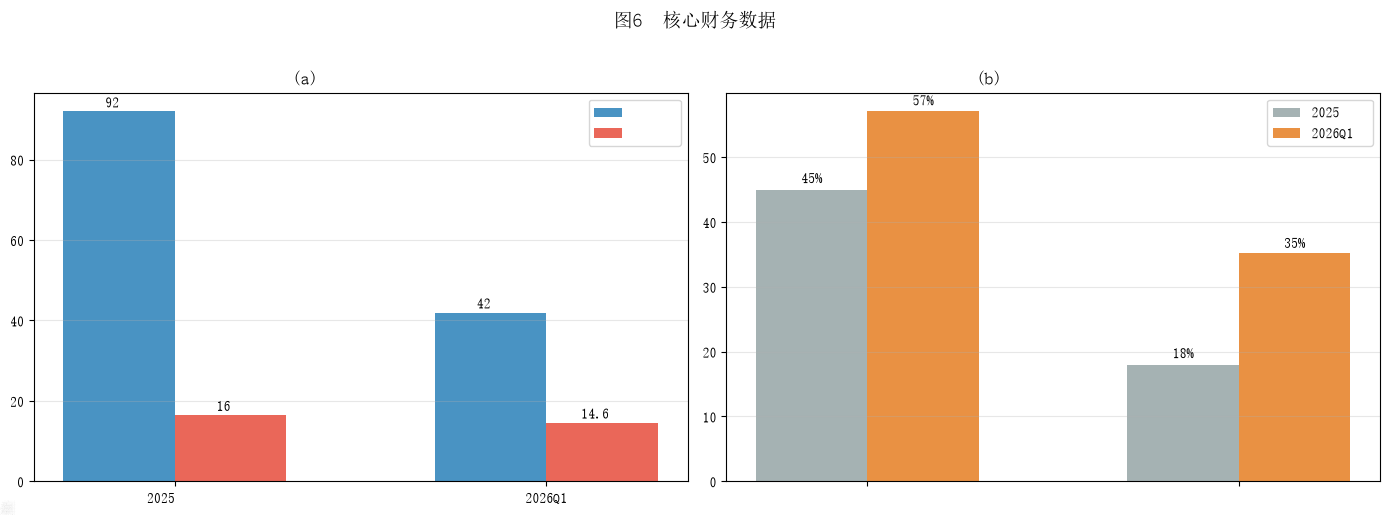

2026Q1一个季度利润14.6亿接近2025全年16.5亿。毛利率45%->57%，净利率18%->35%。


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
cats = ["2025全年","2026Q1"]
ax1.bar(0-0.15, 92.03, 0.3, label="营收", color="#2980b9", alpha=0.85)
ax1.bar(0+0.15, 16.48, 0.3, label="净利润", color="#e74c3c", alpha=0.85)
ax1.bar(1-0.15, 41.88, 0.3, color="#2980b9", alpha=0.85)
ax1.bar(1+0.15, 14.61, 0.3, color="#e74c3c", alpha=0.85)
ax1.text(0-0.15, 93, "92亿", ha="center", fontsize=10, weight="bold")
ax1.text(0+0.15, 17.5, "16亿", ha="center", fontsize=10, weight="bold")
ax1.text(1-0.15, 43, "42亿", ha="center", fontsize=10, weight="bold")
ax1.text(1+0.15, 15.6, "14.6亿", ha="center", fontsize=10, weight="bold")
ax1.set_xticks([0,1]); ax1.set_xticklabels(cats)
ax1.set_title("(a) 营收与净利润"); ax1.legend(); ax1.grid(axis="y",alpha=0.3)
ax2.bar(0-0.15, 45, 0.3, label="2025全年", color="#95a5a6", alpha=0.85)
ax2.bar(0+0.15, 57.08, 0.3, label="2026Q1", color="#e67e22", alpha=0.85)
ax2.bar(1-0.15, 17.9, 0.3, color="#95a5a6", alpha=0.85)
ax2.bar(1+0.15, 35.16, 0.3, color="#e67e22", alpha=0.85)
ax2.text(0-0.15, 46, "45%", ha="center", fontsize=10, weight="bold")
ax2.text(0+0.15, 58, "57%", ha="center", fontsize=10, weight="bold")
ax2.text(1-0.15, 19, "18%", ha="center", fontsize=10, weight="bold")
ax2.text(1+0.15, 36, "35%", ha="center", fontsize=10, weight="bold")
ax2.set_xticks([0,1]); ax2.set_xticklabels(["毛利率","净利率"])
ax2.set_title("(b) 毛利率与净利率"); ax2.legend(); ax2.grid(axis="y",alpha=0.3)
fig.suptitle("图6  核心财务数据", fontsize=14, weight="bold", y=1.02)
fig.tight_layout(); plt.show()
print("2026Q1一个季度利润14.6亿接近2025全年16.5亿。毛利率45%->57%，净利率18%->35%。")

---
## 9. 综合总结

| 维度 | 结论 |
|------|------|
| 价格走势 | 一年+474.3%，底部盘整->主升浪->高位波动 |
| 均线系统 | MA5/MA20/MA60多头排列，中长期趋势完好 |
| MACD | 零轴上方强势区，但红柱缩短动能衰减 |
| RSI | 超买区(>70)，短期回调风险 |
| 成交量 | 从地量到放量，量价配合良好 |
| 估值 | 静态PE高但2026E动态PE仅约7.5倍 |
| 财务 | 2026Q1净利润+522%，毛利率57% |

**关键位:** 支撑600/500元，阻力846.66/800元

> 免责声明: 仅供参考，不构成投资建议。
